
# Loan Default Risk Analysis Project

## Objective
This project analyzes borrower FICO scores and predicts:

- Probability of Default (PD)
- Expected Loss (EL)

using bucket-based risk segmentation.

---

## Key Insights Added

### Why FICO Score?
FICO score represents the creditworthiness of a borrower.

- Higher FICO → Lower risk
- Lower FICO → Higher risk

---

### Why Bucketization?
Instead of treating every FICO score individually:

- We divide scores into groups (buckets)
- Makes risk analysis easier
- Helps banks build credit policies

---

### Why Probability of Default (PD)?
PD helps financial institutions estimate:

- Which borrowers are risky
- Future loan losses
- Credit risk exposure

---

### Why Expected Loss?
Expected Loss estimates:

Expected Loss = PD × LGD × Loan Amount

Where:
- PD = Probability of Default
- LGD = Loss Given Default
- Recovery Rate = Amount bank can recover

---

## Business Understanding
Banks use this approach for:

- Loan approval
- Risk pricing
- Credit card limits
- Portfolio risk management


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\rajpu\Downloads\Net\Task 3 and 4_Loan_Data.csv")

df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [5]:

fico_scores = df['fico_score']

defaults = df['default']

In [6]:
# Create 10 quantile-based buckets

df['fico_bucket'] = pd.qcut(
    df['fico_score'],
    q=10,
    duplicates='drop'
)

In [7]:
bucket_summary = df.groupby('fico_bucket').agg({

    'default': ['count', 'sum', 'mean'],
    'fico_score': ['min', 'max', 'mean']

})

bucket_summary.columns = [

    'Total Borrowers',
    'Defaults',
    'PD',
    'Min FICO',
    'Max FICO',
    'Avg FICO'
]
bucket_summary = bucket_summary.reset_index()

print(bucket_summary)


        fico_bucket  Total Borrowers  Defaults        PD  Min FICO  Max FICO  \
0  (407.999, 560.0]             1017       499  0.490659       408       560   
1    (560.0, 587.0]             1033       318  0.307841       561       587   
2    (587.0, 607.0]              987       246  0.249240       588       607   
3    (607.0, 623.0]              984       179  0.181911       608       623   
4    (623.0, 638.0]              992       173  0.174395       624       638   
5    (638.0, 653.0]              997       128  0.128385       639       653   
6    (653.0, 670.0]             1027       108  0.105161       654       670   
7    (670.0, 688.0]              970        92  0.094845       671       688   
8    (688.0, 714.0]             1005        72  0.071642       689       714   
9    (714.0, 850.0]              988        36  0.036437       715       850   

     Avg FICO  
0  529.508358  
1  575.357212  
2  597.900709  
3  615.629065  
4  631.071573  
5  646.050150  
6  661.

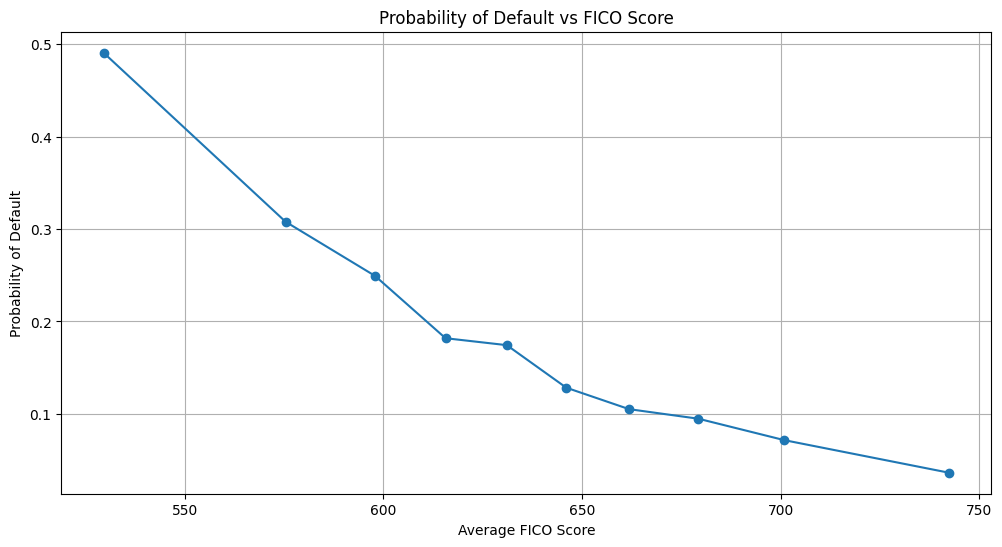

In [8]:

plt.figure(figsize=(12,6))

plt.plot(
    bucket_summary['Avg FICO'],
    bucket_summary['PD'],
    marker='o'
)

plt.title('Probability of Default vs FICO Score')

plt.xlabel('Average FICO Score')

plt.ylabel('Probability of Default')

plt.grid(True)

plt.show()


In [9]:

def predict_pd_from_fico(fico_score):
    """
    Predict probability of default using FICO buckets
    """

    for _, row in bucket_summary.iterrows():

        if (
            fico_score >= row['Min FICO']
            and fico_score <= row['Max FICO']
        ):

            return round(row['PD'], 4)

    return None

In [10]:
def calculate_expected_loss(
    fico_score,
    loan_amount,
    recovery_rate=0.10
):
    """
    Calculate expected loss using FICO-based PD
    """

    pd_probability = predict_pd_from_fico(fico_score)

    lgd = 1 - recovery_rate

    expected_loss = (
        pd_probability
        * lgd
        * loan_amount
    )

    return {
        "FICO Score": fico_score,
        "Probability of Default": round(pd_probability, 4),
        "Expected Loss": round(expected_loss, 2)
    }

In [11]:
result = calculate_expected_loss(

    fico_score=620,
    loan_amount=250000

)

print(result)

{'FICO Score': 620, 'Probability of Default': 0.1819, 'Expected Loss': 40927.5}



# Final Business Insights

## Observations

- Borrowers with low FICO scores have higher default probability.
- High FICO borrowers are generally safer.
- Expected Loss increases when:
  - Loan amount is high
  - PD is high
  - Recovery rate is low

---

## Real-World Use Cases

This model can be used in:

- Banking
- FinTech
- Credit Risk Teams
- Loan Approval Systems
- Risk Monitoring Dashboards

---

## Possible Improvements

Future enhancements may include:

- Logistic Regression Model
- Random Forest / XGBoost
- Time-series credit risk tracking
- Dynamic risk segmentation
- SHAP explainability
